In [1]:
# Week 4: Statistical Analysis and Predictive Modeling
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned dataset

df = pd.read_csv("online_retail_cleaned.csv")

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

# Display the first few records
display(df.head())

Dataset loaded successfully!
Dataset shape: (524878, 14)


C:\Users\user\AppData\Local\Temp\ipykernel_26576\434051821.py:3: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("online_retail_cleaned.csv")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday


In [3]:
# Dataset structure and data types

print("COLUMN NAMES:")
print(df.columns.tolist())

print("\nDATA TYPES:")
print(df.dtypes)

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nDATASET SUMMARY:")
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")

COLUMN NAMES:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalSales', 'Year', 'Month', 'MonthName', 'Day', 'DayOfWeek']

DATA TYPES:
InvoiceNo       object
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
TotalSales     float64
Year             int64
Month            int64
MonthName          str
Day              int64
DayOfWeek          str
dtype: object

MISSING VALUES:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
TotalSales          0
Year                0
Month               0
MonthName           0
Day                 0
DayOfWeek           0
dtype: int64

DATASET SUMMARY:
Total Rows: 524,878
Total Columns: 14


In [4]:
# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Summary statistics for key numerical variables
numerical_columns = ['Quantity', 'UnitPrice', 'TotalSales']

print("DESCRIPTIVE STATISTICS")
print("-" * 50)

display(df[numerical_columns].describe().round(2))

print("\nSALES SUMMARY")
print("-" * 50)
print(f"Total Revenue: £{df['TotalSales'].sum():,.2f}")
print(f"Average Transaction Value: £{df['TotalSales'].mean():,.2f}")
print(f"Median Transaction Value: £{df['TotalSales'].median():,.2f}")

DESCRIPTIVE STATISTICS
--------------------------------------------------


,Quantity,UnitPrice,TotalSales
count,524878.00,524878.00,524878.00
mean,10.62,3.92,20.28
std,156.28,36.09,271.69
min,1.00,0.00,0.00
25%,1.00,1.25,3.90
50%,4.00,2.08,9.92
75%,11.00,4.13,17.70
max,80995.00,13541.33,168469.60



SALES SUMMARY
--------------------------------------------------
Total Revenue: £10,642,110.80
Average Transaction Value: £20.28
Median Transaction Value: £9.92


In [5]:
# Correlation analysis

correlation_columns = ['Quantity', 'UnitPrice', 'TotalSales']

correlation_matrix = df[correlation_columns].corr()

print("CORRELATION MATRIX")
print("-" * 50)
display(correlation_matrix.round(3))

CORRELATION MATRIX
--------------------------------------------------


,Quantity,UnitPrice,TotalSales
Quantity,1.000,-0.004,0.907
UnitPrice,-0.004,1.000,0.137
TotalSales,0.907,0.137,1.000


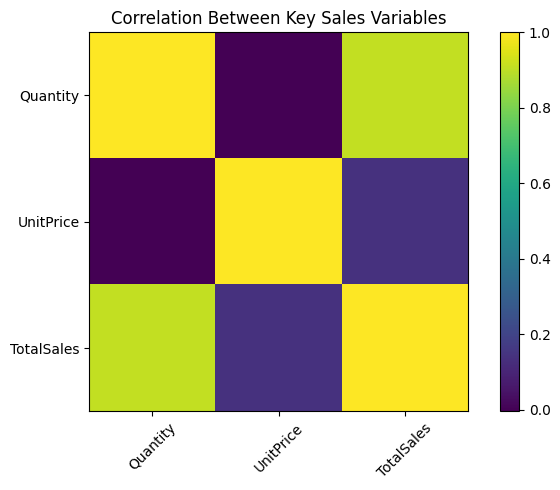

In [6]:
# Correlation matrix visualization using Matplotlib

plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45)
plt.yticks(range(len(correlation_columns)), correlation_columns)

plt.title("Correlation Between Key Sales Variables")
plt.tight_layout()
plt.show()

In [7]:
# Independent Samples t-Test:
# Compare average transaction sales between weekdays and weekends

df['IsWeekend'] = df['InvoiceDate'].dt.dayofweek >= 5

weekday_sales = df.loc[~df['IsWeekend'], 'TotalSales']
weekend_sales = df.loc[df['IsWeekend'], 'TotalSales']

# Display group statistics
print("WEEKDAY VS WEEKEND SALES")
print("-" * 45)
print(f"Weekday transactions: {len(weekday_sales):,}")
print(f"Weekend transactions: {len(weekend_sales):,}")
print(f"Average weekday sales: £{weekday_sales.mean():,.2f}")
print(f"Average weekend sales: £{weekend_sales.mean():,.2f}")

# Perform Welch's t-test (does not assume equal variances)
t_statistic, p_value = stats.ttest_ind(
    weekday_sales,
    weekend_sales,
    equal_var=False
)

print("\nT-TEST RESULTS")
print("-" * 45)
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the null hypothesis.")
    print("There is a statistically significant difference between weekday and weekend sales.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference between weekday and weekend sales.")

WEEKDAY VS WEEKEND SALES
---------------------------------------------
Weekday transactions: 462,539
Weekend transactions: 62,339
Average weekday sales: £21.26
Average weekend sales: £12.94

T-TEST RESULTS
---------------------------------------------
T-statistic: 18.8241
P-value: 0.000000

Result: Reject the null hypothesis.
There is a statistically significant difference between weekday and weekend sales.


In [8]:
# Chi-Square Test of Independence
# Test whether transaction value category is associated with weekday/weekend

# Create transaction value categories using quartiles
df['SalesCategory'] = pd.qcut(
    df['TotalSales'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# Create a readable day category
df['DayCategory'] = np.where(
    df['IsWeekend'],
    'Weekend',
    'Weekday'
)

# Create contingency table
contingency_table = pd.crosstab(
    df['DayCategory'],
    df['SalesCategory']
)

print("CONTINGENCY TABLE")
print("-" * 50)
display(contingency_table)

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nCHI-SQUARE TEST RESULTS")
print("-" * 50)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the null hypothesis.")
    print("Transaction value category is significantly associated with whether the purchase occurred on a weekday or weekend.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("No statistically significant association was found between transaction value category and day category.")

CONTINGENCY TABLE
--------------------------------------------------


SalesCategory,Low,Medium,High
DayCategory,,,
Weekday,152460,150939,159140
Weekend,26832,21001,14506



CHI-SQUARE TEST RESULTS
--------------------------------------------------
Chi-square statistic: 3712.2144
Degrees of freedom: 2
P-value: 0.000000

Result: Reject the null hypothesis.
Transaction value category is significantly associated with whether the purchase occurred on a weekday or weekend.


In [9]:
# Create a daily sales dataset for predictive modeling

daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['TotalSales']
    .sum()
    .reset_index()
)

daily_sales.columns = ['Date', 'DailySales']

# Convert Date to datetime
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

# Create time-based predictor variables
daily_sales['Year'] = daily_sales['Date'].dt.year
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Day'] = daily_sales['Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek

# Create a sequential time index to capture the overall trend
daily_sales['TimeIndex'] = range(len(daily_sales))

print("DAILY SALES DATASET CREATED")
print("-" * 45)
print(f"Number of days: {len(daily_sales)}")
print(f"Date range: {daily_sales['Date'].min().date()} to {daily_sales['Date'].max().date()}")

display(daily_sales.head())

DAILY SALES DATASET CREATED
---------------------------------------------
Number of days: 305
Date range: 2010-12-01 to 2011-12-09


,Date,DailySales,Year,Month,Day,DayOfWeek,TimeIndex
0,2010-12-01,58776.79,2010,12,1,2,0
1,2010-12-02,47629.42,2010,12,2,3,1
2,2010-12-03,46898.63,2010,12,3,4,2
3,2010-12-05,31364.63,2010,12,5,6,3
4,2010-12-06,54624.15,2010,12,6,0,4


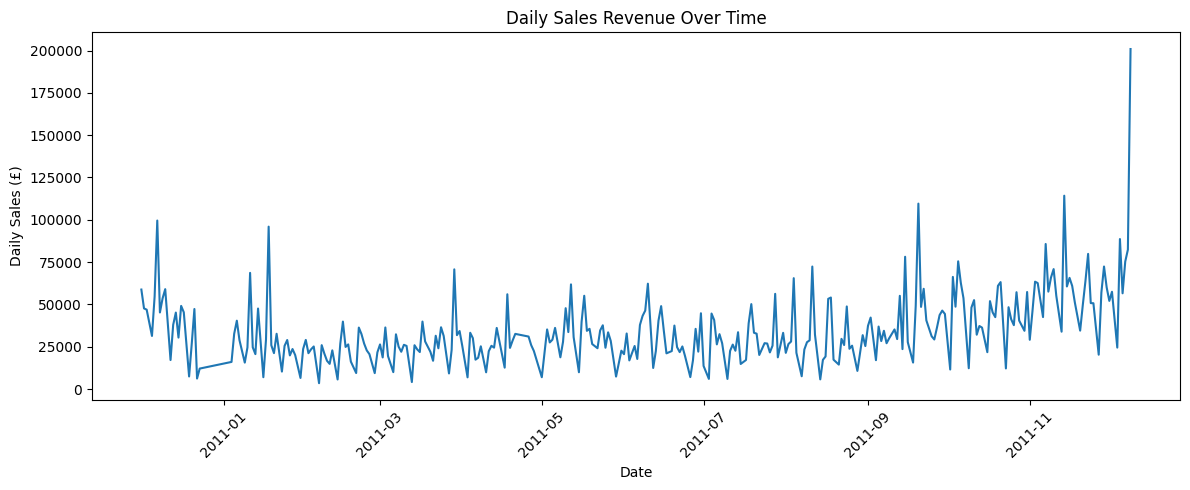

In [10]:
# Visualize daily sales over time

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales['Date'],
    daily_sales['DailySales']
)

plt.title("Daily Sales Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Sales (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Prepare features and target variable

features = ['TimeIndex', 'Month', 'Day', 'DayOfWeek']

X = daily_sales[features]
y = daily_sales['DailySales']

# Use the first 80% of observations for training
# and the most recent 20% for testing

split_index = int(len(daily_sales) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("TRAIN-TEST SPLIT")
print("-" * 40)
print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")
print(f"Training period: {daily_sales['Date'].iloc[0].date()} to "
      f"{daily_sales['Date'].iloc[split_index - 1].date()}")
print(f"Testing period: {daily_sales['Date'].iloc[split_index].date()} to "
      f"{daily_sales['Date'].iloc[-1].date()}")

TRAIN-TEST SPLIT
----------------------------------------
Training observations: 244
Testing observations: 61
Training period: 2010-12-01 to 2011-09-29
Testing period: 2011-09-30 to 2011-12-09


In [12]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

print("LINEAR REGRESSION MODEL TRAINED SUCCESSFULLY!")

# Display model coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print("\nMODEL COEFFICIENTS:")
display(coefficients.round(2))

print(f"\nIntercept: {model.intercept_:,.2f}")

LINEAR REGRESSION MODEL TRAINED SUCCESSFULLY!

MODEL COEFFICIENTS:


,Feature,Coefficient
0,TimeIndex,-11.14
1,Month,1535.78
2,Day,2.97
3,DayOfWeek,-2976.40



Intercept: 30,570.37


In [13]:
# Make predictions on the test dataset
y_pred = model.predict(X_test)

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION RESULTS")
print("-" * 40)
print(f"Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MODEL EVALUATION RESULTS
----------------------------------------
Mean Absolute Error (MAE): £21,067.19
Root Mean Squared Error (RMSE): £31,243.56
R² Score: -0.3547


In [15]:
# Create a comparison DataFrame using the test set dates
comparison = pd.DataFrame({
    'Date': daily_sales.loc[y_test.index, 'Date'].values,
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print("ACTUAL VS PREDICTED SALES")
print("-" * 40)
display(comparison.head(10))

ACTUAL VS PREDICTED SALES
----------------------------------------


,Date,Actual Sales,Predicted Sales
0,2011-09-30,44347.06,29856.421301
1,2011-10-02,11531.56,25345.222384
2,2011-10-03,66243.94,43195.460760
3,2011-10-04,48652.54,40210.878332
4,2011-10-05,75460.77,37226.295904
5,2011-10-06,62761.92,34241.713476
6,2011-10-07,53692.50,31257.131048
7,2011-10-09,12273.10,25299.111112
8,2011-10-10,48121.66,43149.349489
9,2011-10-11,52537.31,40164.767061


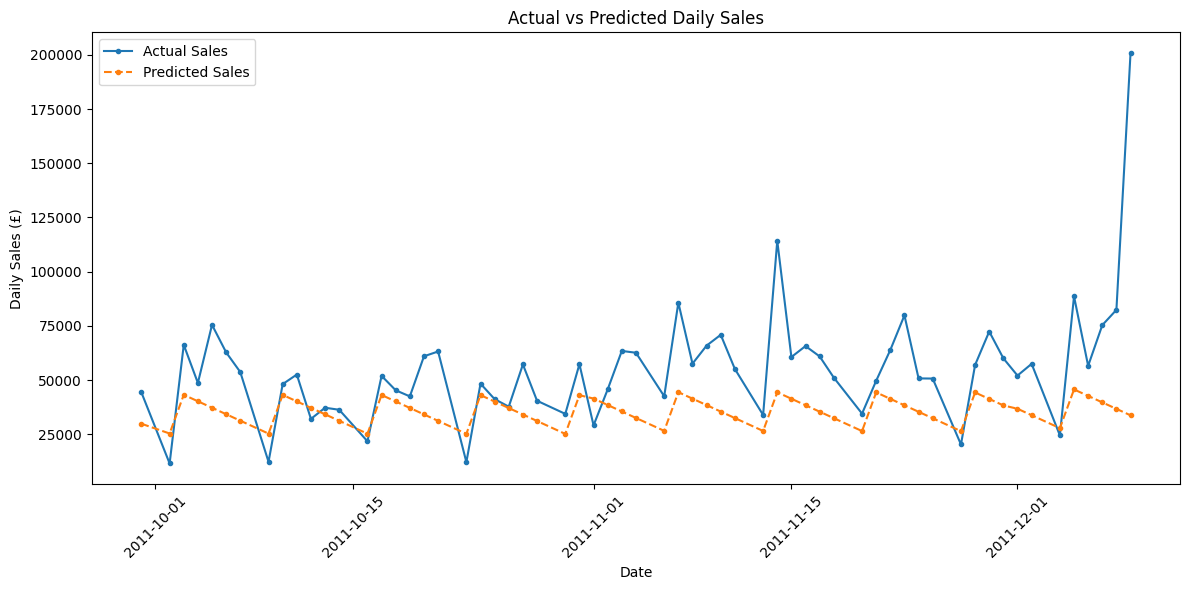

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison['Date'],
    comparison['Actual Sales'],
    label='Actual Sales',
    marker='o',
    markersize=3
)

plt.plot(
    comparison['Date'],
    comparison['Predicted Sales'],
    label='Predicted Sales',
    linestyle='--',
    marker='o',
    markersize=3
)

plt.title('Actual vs Predicted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Daily Sales (£)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

RESIDUAL ANALYSIS
----------------------------------------
count        61.000000
mean      18761.128621
std       25190.927208
min      -13813.662384
25%        5333.646638
50%       15396.419868
75%       27279.046169
max      167168.173820
Name: Residual, dtype: float64


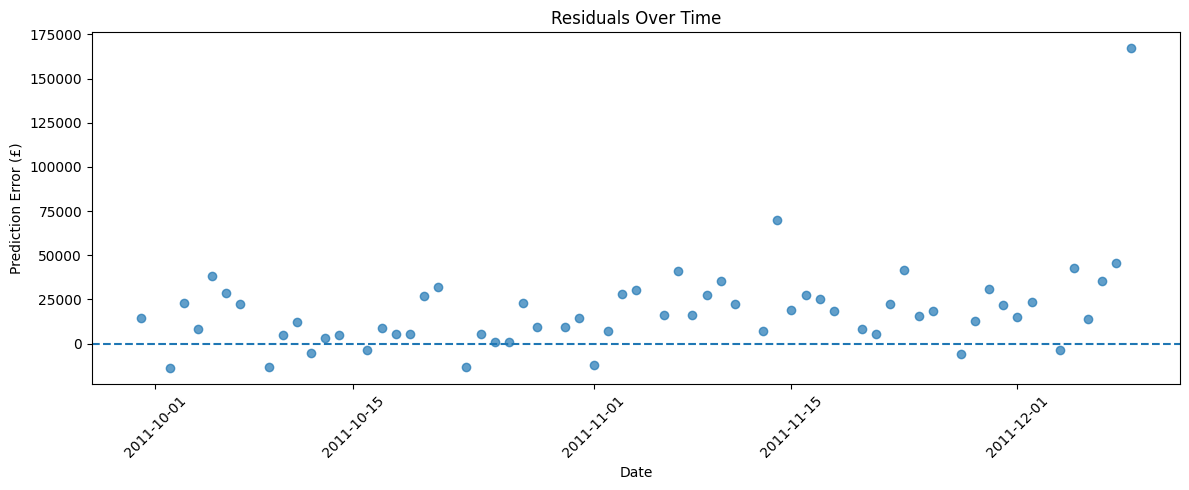

In [17]:
# Calculate residuals (prediction errors)
comparison['Residual'] = comparison['Actual Sales'] - comparison['Predicted Sales']

# Display residual summary
print("RESIDUAL ANALYSIS")
print("-" * 40)
print(comparison['Residual'].describe())

# Plot residuals over time
plt.figure(figsize=(12, 5))

plt.scatter(
    comparison['Date'],
    comparison['Residual'],
    alpha=0.7
)

plt.axhline(y=0, linestyle='--')

plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Prediction Error (£)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()